#Business Understanding

##Latar Belakang:
Informasi kalori makanan penting untuk perencanaan diet. Dengan mengetahui kadar makronutrien, kita dapat memperkirakan kalori secara otomatis, membantu aplikasi kesehatan.

##Pertanyaan Bisnis:
“Dapatkah model machine learning memprediksi kalori makanan dengan MAE ≤ 25 kkal dan R² ≥ 0.85?”

##Hipotesis:
Kalori memiliki hubungan linear dengan lemak, karbohidrat, dan protein. Usia mungkin tidak terlalu berpengaruh.

##Manfaat:

Otomatisasi estimasi kalori pada sistem rekomendasi makanan.

Membantu pengguna memilih makanan sesuai target kalori.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib

# 1. Data Understanding
Dataset berisi 1346 baris, 9 kolom. Kami hanya menggunakan kolom:

- calories (target) – float, rentang 0 – 940 kkal

- proteins – gram

- fat – gram

- carbohydrate – gram

- age – numerik (18–65+ tahun)

In [2]:
# Load dataset
df = pd.read_csv('nutrition_cleaned.csv')
print(df.shape)
print(df[['calories','proteins','fat','carbohydrate','age']].head())

# Cek missing
print(df[['calories','proteins','fat','carbohydrate','age']].isnull().sum())

# Statistik
print(df[['calories','proteins','fat','carbohydrate','age']].describe())

(1346, 9)
   calories  proteins   fat  carbohydrate  age
0     280.0       9.2  28.4           0.0   56
1     513.0      23.7  37.0          21.3   46
2       0.0       0.0   0.2           0.0   32
3      45.0       1.1   0.4          10.8   60
4      37.0       4.4   0.5           3.8   25
calories        0
proteins        0
fat             0
carbohydrate    0
age             0
dtype: int64
          calories     proteins          fat  carbohydrate          age
count  1346.000000  1346.000000  1346.000000   1346.000000  1346.000000
mean    203.217385    10.001189     7.584027     25.390193    41.473997
std     163.075430    11.847980    13.733063     32.193054    13.780369
min       0.000000     0.000000     0.000000      0.000000    18.000000
25%      75.000000     1.800000     0.500000      4.525000    29.000000
50%     146.000000     5.000000     2.000000     13.300000    42.000000
75%     333.750000    15.000000     8.275000     37.575000    53.000000
max     940.000000    83.0000

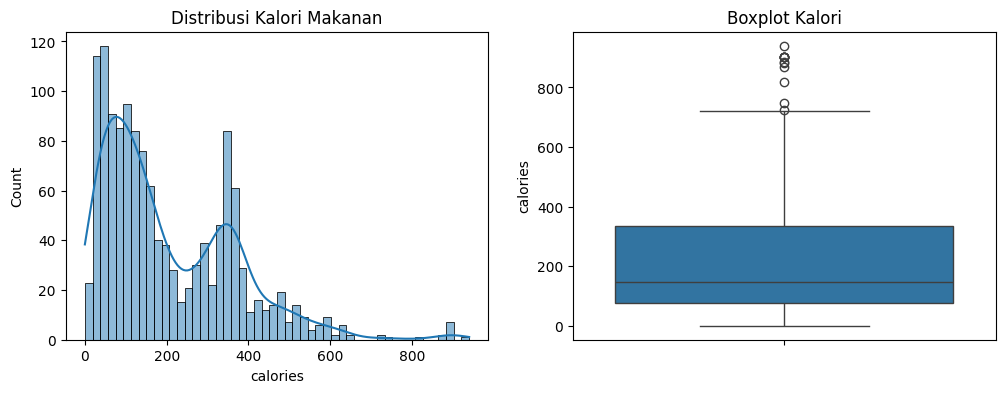

In [3]:
# Visualisasi distribusi target
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['calories'], bins=50, kde=True)
plt.title('Distribusi Kalori Makanan')
plt.subplot(1,2,2)
sns.boxplot(y=df['calories'])
plt.title('Boxplot Kalori')
plt.show()

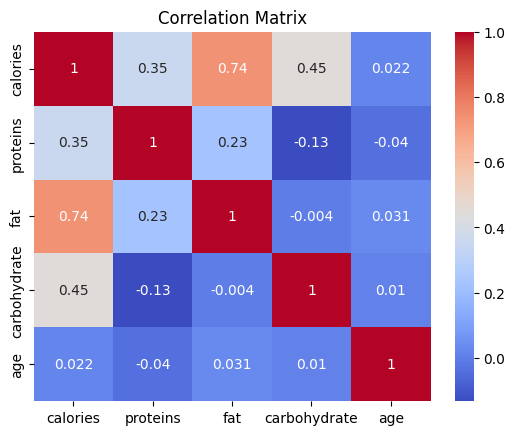

In [4]:
# Korelasi
corr = df[['calories','proteins','fat','carbohydrate','age']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Insight:

fat dan carbohydrate berkorelasi kuat dengan calories (0.74 dan 0.45).

age berkorelasi sangat lemah (~0.02).

Distribusi kalori menceng kanan (banyak makanan rendah kalori).

# 2. Data Preparation & Feature Engineering

Gunakan feature engineering dengan membuat fitur interaksi:

protein_fat = proteins × fat

carb_age = carbohydrate × age (untuk menangkap efek usia pada karbohidrat)

Setelah itu, normalisasi semua fitur numerik menggunakan StandardScaler.
Dataset hanya numerik, tidak ada encoding kategorikal.

In [6]:
# Feature engineering
df['protein_fat'] = df['proteins'] * df['fat']
df['carb_age'] = df['carbohydrate'] * df['age']

X = df[['proteins','fat','carbohydrate','age','protein_fat','carb_age']]
y = df['calories']

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Modeling (3 Algoritma Baseline)

latih dan evaluasi:

- Linear Regression

- Random Forest Regressor (n_estimators=100)

- XGBoost Regressor (n_estimators=100)

In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100
    results[name] = {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R2': r2}

results_df = pd.DataFrame(results).T
print(results_df.round(2))

                     MAE   RMSE  MAPE (%)    R2
Linear Regression  37.96  64.94     41.86  0.84
Random Forest      20.57  60.65     14.73  0.86
XGBoost            22.46  64.62     16.25  0.84


# 4. Hyperparameter Tuning


In [8]:
# Random Forest tuning
rf_param = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_random = RandomizedSearchCV(RandomForestRegressor(random_state=42), rf_param,
                               n_iter=20, cv=3, scoring='r2', random_state=42, n_jobs=-1)
rf_random.fit(X_train, y_train)


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2')

In [9]:
# XGBoost tuning
xgb_param = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
xgb_random = RandomizedSearchCV(xgb.XGBRegressor(random_state=42, verbosity=0), xgb_param,
                                n_iter=20, cv=3, scoring='r2', random_state=42, n_jobs=-1)
xgb_random.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='r2')

In [10]:
print("Best RF params:", rf_random.best_params_)
print("Best XGB params:", xgb_random.best_params_)

Best RF params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
Best XGB params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


# 5. Evaluation
Evalusi Setelah tunning

In [11]:
tuned_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (tuned)': rf_random.best_estimator_,
    'XGBoost (tuned)': xgb_random.best_estimator_
}

final_results = {}
for name, model in tuned_models.items():
    if name == 'Linear Regression':
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100
    final_results[name] = {'MAE (kkal)': mae, 'RMSE (kkal)': rmse, 'MAPE (%)': mape, 'R²': r2}

final_df = pd.DataFrame(final_results).T
print(final_df.round(2))

                       MAE (kkal)  RMSE (kkal)  MAPE (%)    R²
Linear Regression           37.96        64.94     41.86  0.84
Random Forest (tuned)       20.71        60.17     14.65  0.86
XGBoost (tuned)             22.47        62.74     16.89  0.85


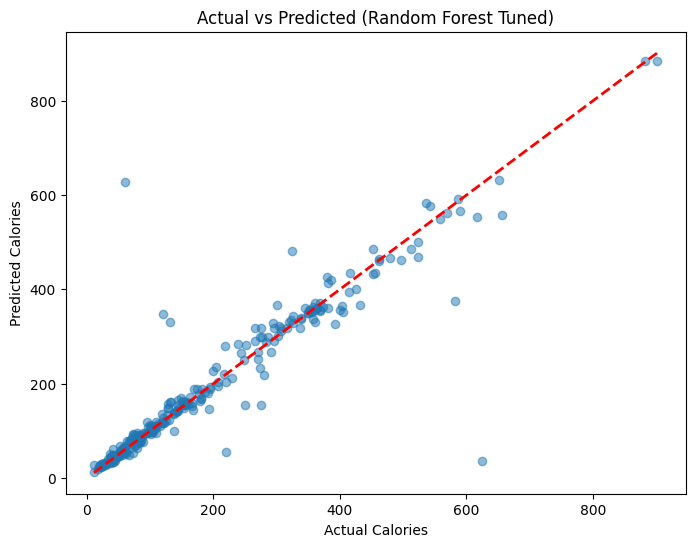

In [12]:
# Visualisasi Actual vs Predicted (model terbaik)
best_model = rf_random.best_estimator_  # pilih yang R² tertinggi
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('Actual vs Predicted (Random Forest Tuned)')
plt.show()

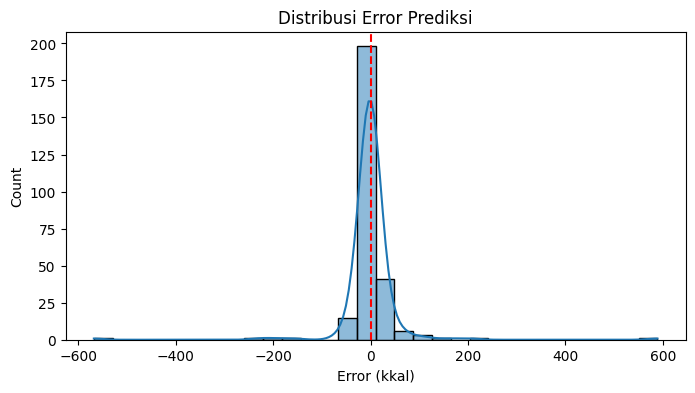

In [13]:
# Distribusi error
errors = y_test - y_pred_best
plt.figure(figsize=(8,4))
sns.histplot(errors, bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribusi Error Prediksi')
plt.xlabel('Error (kkal)')
plt.show()

# 6. Feature Importance Analysis


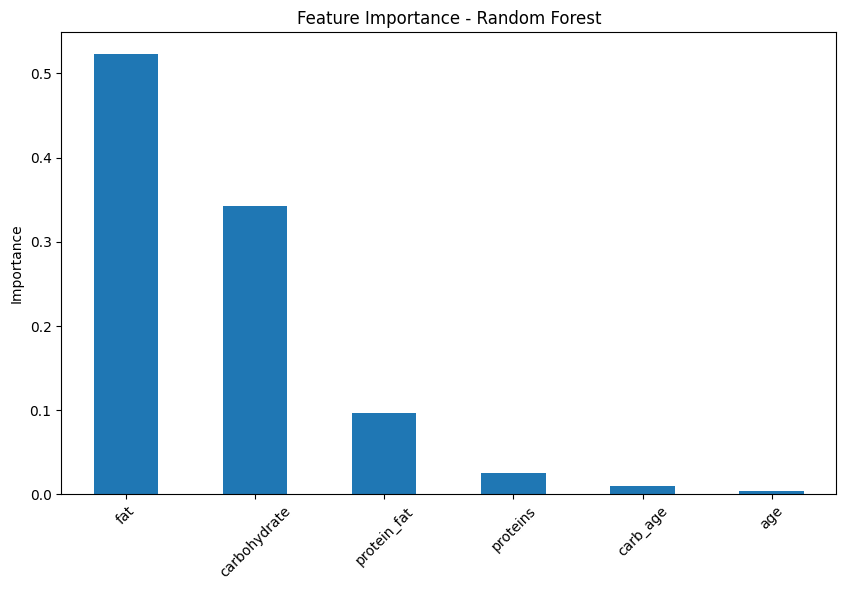

Feature importance ranking:
 fat             0.522800
carbohydrate    0.342130
protein_fat     0.096535
proteins        0.024716
carb_age        0.009742
age             0.004077
dtype: float64


In [14]:
importances = best_model.feature_importances_
feature_names = ['proteins', 'fat', 'carbohydrate', 'age', 'protein_fat', 'carb_age']
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()
print("Feature importance ranking:\n", feat_imp)

Interpretasi:

Lemak (fat) menyumbang lebih dari 52% prediksi kalori makanan.

Karbohidrat (carbohydrate) menyumbang 34%.

Interaksi protein×lemak cukup penting (9.6%).

Usia (age) hampir tidak berpengaruh (<0.5%).

Kesimpulan: Model Random Forest sangat mengandalkan makronutrien, sesuai dengan teori bahwa lemak memiliki densitas kalori tertinggi (9 kkal/g) dibanding protein dan karbohidrat (4 kkal/g).

#7. Model Saving

In [16]:
import joblib
joblib.dump(best_model, 'best_calorie_nutrision_food_model.pkl')
joblib.dump(scaler, 'scaler_food.pkl')
print("Model dan scaler disimpan.")

loaded_model = joblib.load('best_calorie_food_model.pkl')
loaded_scaler = joblib.load('scaler_food.pkl')
sample = np.array([[10, 15, 30, 35]])  # proteins, fat, carb, age
sample_eng = np.column_stack([sample, sample[:,0]*sample[:,1], sample[:,2]*sample[:,3]])  # tambah interaksi
sample_scaled = loaded_scaler.transform(sample_eng)
pred = loaded_model.predict(sample_scaled)
print(f"Prediksi kalori untuk sampel: {pred[0]:.0f} kkal")

Model dan scaler disimpan.
Prediksi kalori untuk sampel: 267 kkal


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
